In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statannotations.Annotator import Annotator
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
df = pd.read_csv(r'../pre-calculated_data/nanopore.csv')
df

,Sample,Total GB,N50 length,Mean Q,Site,Original_sample_name
0,CPSNJ01,45.386270,12017,15.8,NanJing_8,CPSNJ01_350
1,CPSNJ02,57.192760,15910,15.7,NanJing_8,CPSNJ02_350
2,CPSNJ03,46.479399,16752,16.0,NanJing_8,CPSNJ03_350
3,CPSNJ04,71.459105,17489,16.1,NanJing_8,CPSNJ04_350
4,CPSNJ08,48.708406,10742,15.0,NanJing_8,CPSNJ08_350
5,CPSNJ09,67.587256,17853,15.7,NanJing_8,CPSNJ09_350
6,CPSNJ10,59.134384,18330,15.7,NanJing_8,CPSNJ10_350
7,CPSNJ11,54.003233,19505,15.7,NanJing_8,CPSNJ11_350
8,CPSNJ13,47.460343,19467,15.9,NanJing_8,CPSNJ13_350
9,CPSNJ14,54.746032,19967,15.9,NanJing_8,CPSNJ14_350


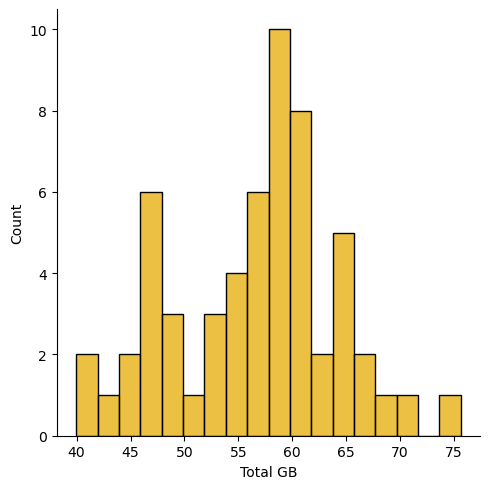

In [3]:
sns.displot(data=df,
            x='Total GB',
            color='#e6ab02',binwidth=2)

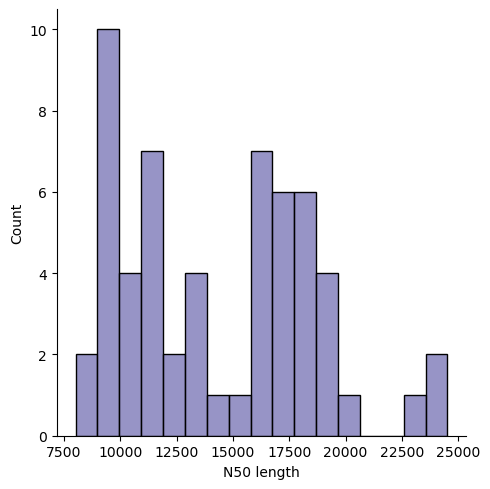

In [4]:
sns.displot(data=df,
            x='N50 length',
            color='#7570b3',binwidth=1000)

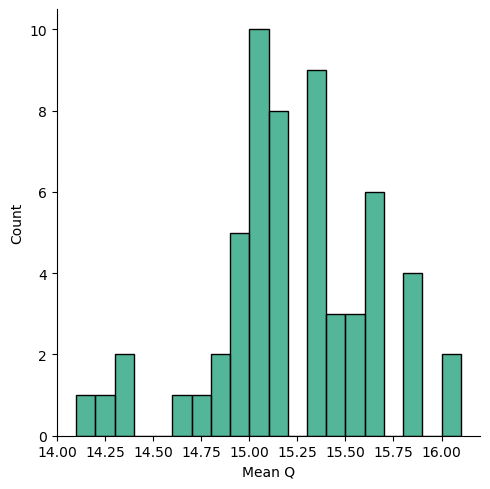

In [5]:
sns.displot(data=df,
            x='Mean Q',
            color='#1b9e77',binwidth=0.1)

In [6]:
smag = pd.read_csv('../smag_comparison/results/SMAG_diversity.csv', index_col=0).sort_values(by="Ecosystem")
smag

,simpson,chao1,shannon,Site,Ecosystem
SRR25158392,0.996791,1927.848649,7.251344,SMAG,Agricultural Land
SRR25158373,0.996829,2645.625450,7.378819,SMAG,Agricultural Land
SRR25158323,0.997668,2522.566674,7.554158,SMAG,Agricultural Land
SRR25158376,0.997857,3116.173022,7.601568,SMAG,Agricultural Land
SRR25158333,0.998396,3025.407629,7.869758,SMAG,Agricultural Land
...,...,...,...,...,...
SRR25158354,0.998803,1357.020351,7.947961,SMAG,Wetland
SRR25158188,0.997265,1921.534257,7.285341,SMAG,Wetland
SRR25158311,0.998440,1667.942983,7.794140,SMAG,Wetland
SRR25158346,0.997386,1390.271129,7.526948,SMAG,Wetland


In [7]:
others = pd.read_csv('../pre-calculated_data/alpha_diversity_without_smag.csv', index_col=0).drop("Observed OTUs", axis=1)
others["Ecosystem"] = "Urban"
others.loc[others["Site"] == "Dog", "Ecosystem"] = "Canine Gut"
others

,Site,chao1,shannon,simpson,Ecosystem
CPSNJ01_350,Nanjing,4482.000000,7.550584,0.999247,Urban
CPSNJ02_350,Nanjing,5325.478947,7.716052,0.999457,Urban
CPSNJ03_350,Nanjing,4044.156057,7.459325,0.999198,Urban
CPSNJ04_350,Nanjing,4996.046512,7.613989,0.999339,Urban
CPSNJ08_350,Nanjing,5911.825641,7.698279,0.999287,Urban
...,...,...,...,...,...
D048_350,Dog,1150.055556,2.642535,0.870817,Canine Gut
D049_350,Dog,1010.454545,3.052941,0.868107,Canine Gut
D050_350,Dog,1644.700000,2.431669,0.790104,Canine Gut
D051_350,Dog,1132.789474,2.987304,0.907449,Canine Gut


In [15]:
df = pd.concat([smag, others])
df["Type"] = df['Ecosystem']+" - "+df['Site']
custom_dict =  {"Urban - Nanjing":0, "Urban - Shanghai":1, 'Bare Land - SMAG':2, 'Wetland - SMAG':3,
                'Agricultural Land - SMAG':4, 'Grassland - SMAG':5, 'Forest - SMAG':6, "Canine Gut - Dog":7}
df = df.sort_values(by=['Type'], key=lambda x: x.map(custom_dict))
df

,simpson,chao1,shannon,Site,Ecosystem,Type
CPSNJ11_350,0.999056,3578.688797,7.364014,Nanjing,Urban,Urban - Nanjing
CPSNJ10_350,0.999256,4580.255396,7.571268,Nanjing,Urban,Urban - Nanjing
CPSNJ09_350,0.998940,3278.795567,7.240108,Nanjing,Urban,Urban - Nanjing
CPSNJ08_350,0.999287,5911.825641,7.698279,Nanjing,Urban,Urban - Nanjing
CPSNJ04_350,0.999339,4996.046512,7.613989,Nanjing,Urban,Urban - Nanjing
...,...,...,...,...,...,...
D031_350,0.907553,1022.130435,3.150901,Dog,Canine Gut,Canine Gut - Dog
D030_350,0.942650,1515.105263,3.422197,Dog,Canine Gut,Canine Gut - Dog
D022_350,0.901325,1234.120000,3.063936,Dog,Canine Gut,Canine Gut - Dog
D023_350,0.883762,1400.062500,3.207883,Dog,Canine Gut,Canine Gut - Dog


/tmp/ipykernel_39562/1491782887.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


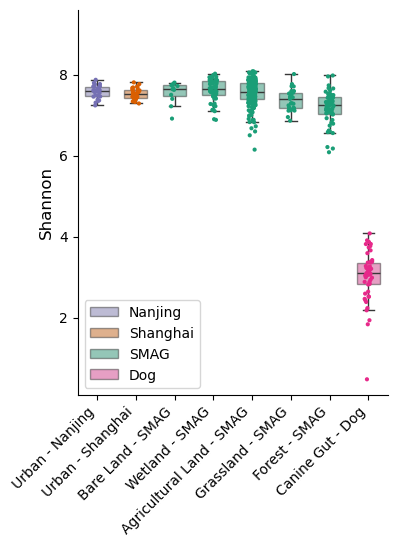

In [20]:
custom_palette = {
    'Nanjing': '#7570b3',
    'Shanghai': '#d95f02',
    'SMAG': '#1b9e77',
    'Dog': '#e7298a',
}

fig, ax = plt.subplots(figsize=(4, 5))
sns.boxplot(data=df, x="Type", y="shannon", color='white', hue="Site", 
             palette=custom_palette,boxprops=dict(alpha=0.5),
            showfliers=False, ax=ax, width=0.6)

sns.stripplot(data=df, x="Type", y="shannon", hue="Site",
             palette=custom_palette, ax=ax,size=3, jitter=True)

y_max = df['shannon'].max()
y_min = df['shannon'].min()
vertical_offset = 0.1 * (y_max - y_min)
current_level = 1  

ax.set_ylim(top=y_max + vertical_offset * (current_level + 1))
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Shannon', fontsize=12)
ax.set_xlabel('')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles[0:4], labels=labels[0:4], loc="lower left")
plt.savefig('supp1_shannon.svg')

/tmp/ipykernel_39562/2387016942.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


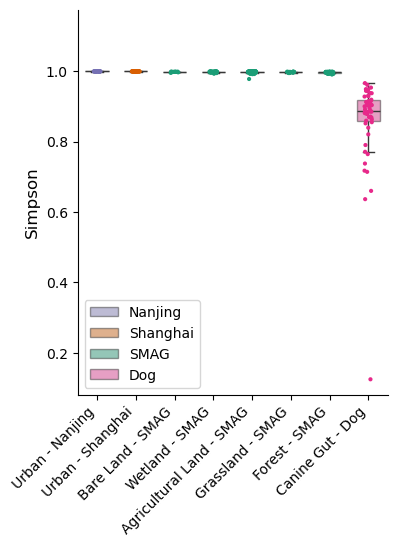

In [21]:
custom_palette = {
    'Nanjing': '#7570b3',
    'Shanghai': '#d95f02',
    'SMAG': '#1b9e77',
    'Dog': '#e7298a',
}

fig, ax = plt.subplots(figsize=(4, 5))
sns.boxplot(data=df, x="Type", y="simpson", color='white', hue="Site", 
             palette=custom_palette,boxprops=dict(alpha=0.5),
            showfliers=False, ax=ax, width=0.6, order=["Urban - Nanjing", "Urban - Shanghai", 'Bare Land - SMAG', 'Wetland - SMAG',
                                                       'Agricultural Land - SMAG', 'Grassland - SMAG', 'Forest - SMAG', "Canine Gut - Dog"])

sns.stripplot(data=df, x="Type", y="simpson", hue="Site",
             palette=custom_palette, ax=ax,size=3, jitter=True, order=["Urban - Nanjing", "Urban - Shanghai", 'Bare Land - SMAG', 'Wetland - SMAG',
                                                       'Agricultural Land - SMAG', 'Grassland - SMAG', 'Forest - SMAG', "Canine Gut - Dog"])

tukey = pairwise_tukeyhsd(endog=df['simpson'], groups=df['Type'], alpha=0.05)
summary = tukey.summary()

significant_pairs = []
for i in range(1, len(summary.data)):
    row = summary.data[i]
    if float(row[3]) < 0.05:
        if "Canine Gut - Dog" not in [row[0], row[1]]:
            group1 = row[0]
            group2 = row[1]
            p_val = float(row[3])
            significant_pairs.append( (group1, group2, p_val) )

group_order = df['Type'].unique()
x_positions = {group: idx for idx, group in enumerate(group_order)}

y_max = df['simpson'].max()
y_min = df['simpson'].min()
vertical_offset = 0.1 * (y_max - y_min)
current_level = 1  
line_props = {'color': 'black', 'linewidth': 1, 'transform': ax.transData}
for pair in significant_pairs:
    group1, group2, p_val = pair
    x1 = x_positions[group1]
    x2 = x_positions[group2]
    if p_val < 0.001:
        symbol = '***'
    elif p_val < 0.01:
        symbol = '**'
    elif p_val < 0.05:
        symbol = '*'
    else:
        continue
    y_top = y_max + (vertical_offset * current_level)
    y_line = y_top - 0.1 * vertical_offset
    ax.plot([x1, x1, x2, x2], 
            [y_line, y_top, y_top, y_line], **line_props)
    ax.text((x1+x2)/2, y_top, symbol, 
            ha='center', va='bottom', 
            fontsize=12, color='black')
    current_level += 1 

ax.set_ylim(top=y_max + vertical_offset * (current_level + 1))
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Simpson', fontsize=12)
ax.set_xlabel('')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles[0:4], labels=labels[0:4], loc="lower left")
plt.savefig('supp1_simpson.svg')

/tmp/ipykernel_39562/1299022900.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


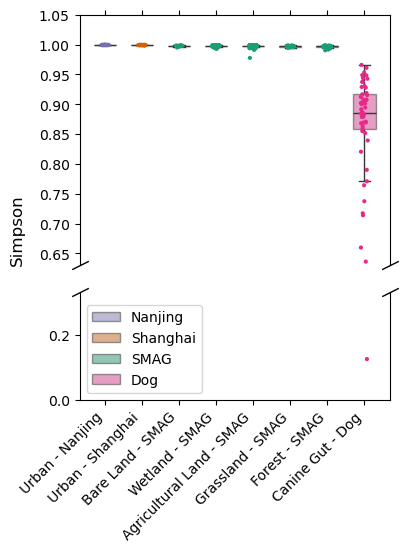

In [24]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, height_ratios=(0.7,0.3), figsize=(4,5))
fig.subplots_adjust(hspace=0.15)  # adjust space between Axes

# plot the same data on both Axes
sns.boxplot(data=df, x="Type", y="simpson", color='white', hue="Site", 
             palette=custom_palette,boxprops=dict(alpha=0.5),
            showfliers=False, ax=ax1, width=0.6)
sns.stripplot(data=df, x="Type", y="simpson", hue="Site",
             palette=custom_palette, ax=ax1,size=3, jitter=True)
sns.boxplot(data=df, x="Type", y="simpson", color='white', hue="Site", 
             palette=custom_palette,boxprops=dict(alpha=0.5),
            showfliers=False, ax=ax2, width=0.6)
sns.stripplot(data=df, x="Type", y="simpson", hue="Site",
             palette=custom_palette, ax=ax2,size=3, jitter=True)

# zoom-in / limit the view to different portions of the data
ax1.set_ylim(.63, 1.05)  # outliers only
ax2.set_ylim(0, .33)  # most of the data

# hide the spines between ax and ax2
ax1.spines.bottom.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # don't put tick labels at the top
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.xaxis.tick_bottom()

d = .5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)


ax1.get_legend().remove()
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles=handles[0:4], labels=labels[0:4], loc="lower left")

ax2.set_ylabel('', fontsize=12)
ax1.set_ylabel('Simpson', fontsize=12, loc="bottom", labelpad=10)
ax2.set_xlabel('')
plt.savefig('supp1_simpson_broken.svg')